Perbandingan penggunaan aplikasi baca webtoon dan karyakarsa di google play store berdasarkan analisis review pengguna.

In [17]:
!pip install google-play-scraper

In [18]:
import pandas as pd
import numpy as np
import re
import string
from google_play_scraper import reviews, Sort
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from collections import Counter

In [20]:
#Scraping data
def scrape_reviews(app_id, app_name, count=5000):
    result, _ = reviews(
        app_id,
        lang='id',
        country='id',
        sort=Sort.MOST_RELEVANT,
        count=count,
        filter_score_with=None
    )
    if not result:
        df = pd.DataFrame(columns=['content', 'score', 'at'])
    else:
        df = pd.DataFrame(result)
        required_cols = ['content', 'score', 'at']
        for col in required_cols:
            if col not in df.columns:
                df[col] = None
        df = df[['content', 'score', 'at']]
        df.rename(columns={'content':'text'}, inplace=True)
        df['app'] = app_name
    return df

df_webtoon = scrape_reviews('com.naver.linewebtoon', 'Webtoon', 5000)
df_karyakarsa = scrape_reviews('com.karyakarsa', 'Karyakarsa', 5000)

# Gabungkan dataset
df = pd.concat([df_webtoon, df_karyakarsa], ignore_index=True)

In [21]:
#Preprocessing
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'\b\w{1,3}\b', '', text)  # hapus kata < 3 huruf
    text = re.sub(r'\d+', '', text)  # hapus angka
    text = re.sub(r'[^\x00-\x7F]+','', text)  # hapus non ASCII
    text = text.translate(str.maketrans('', '', string.punctuation))  # hapus tanda baca
    text = ' '.join([stemmer.stem(w) for w in text.split() if w not in stop_words])
    return text

df['clean_text'] = df['text'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


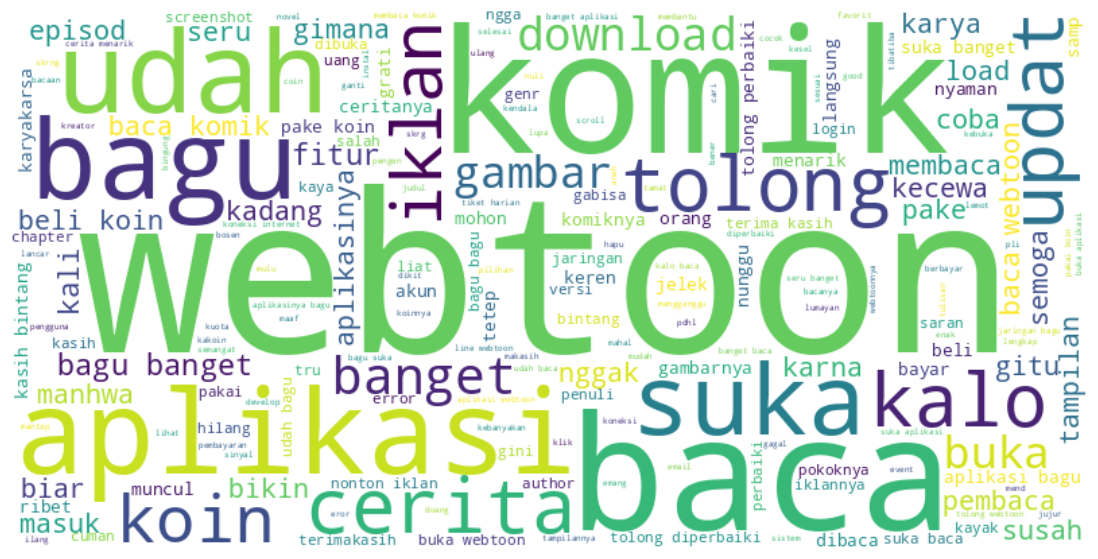

In [24]:
#Wordcloud
all_words = ' '.join(df['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

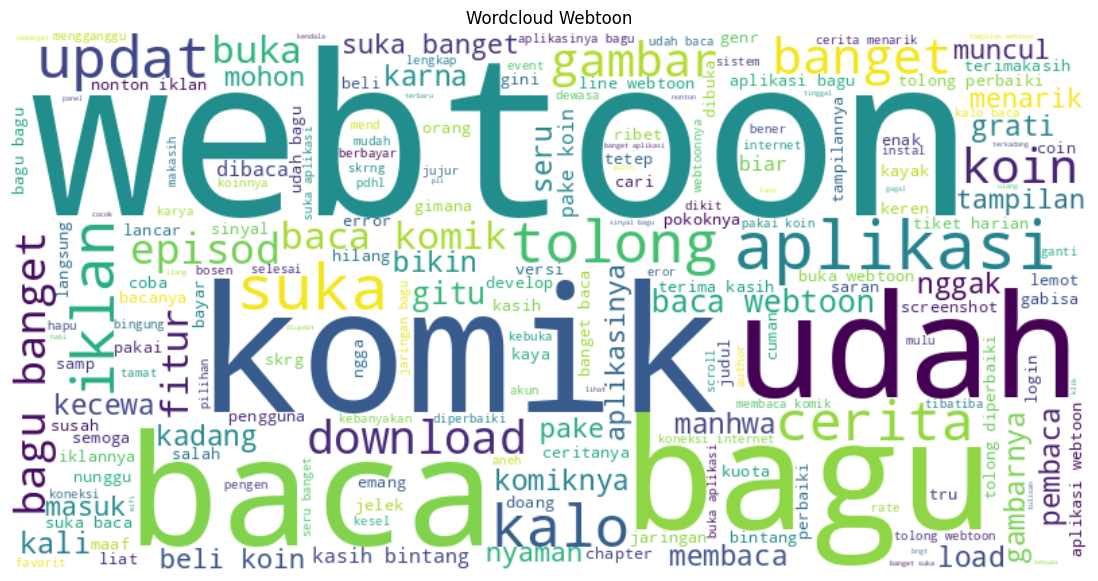

In [22]:
webtoon_words = ' '.join(df[df['app']=='Webtoon']['clean_text'])
wordcloud_webtoon = WordCloud(width=800, height=400, background_color='white').generate(webtoon_words)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud_webtoon, interpolation='bilinear')
plt.axis('off')
plt.title("Wordcloud Webtoon")
plt.show()

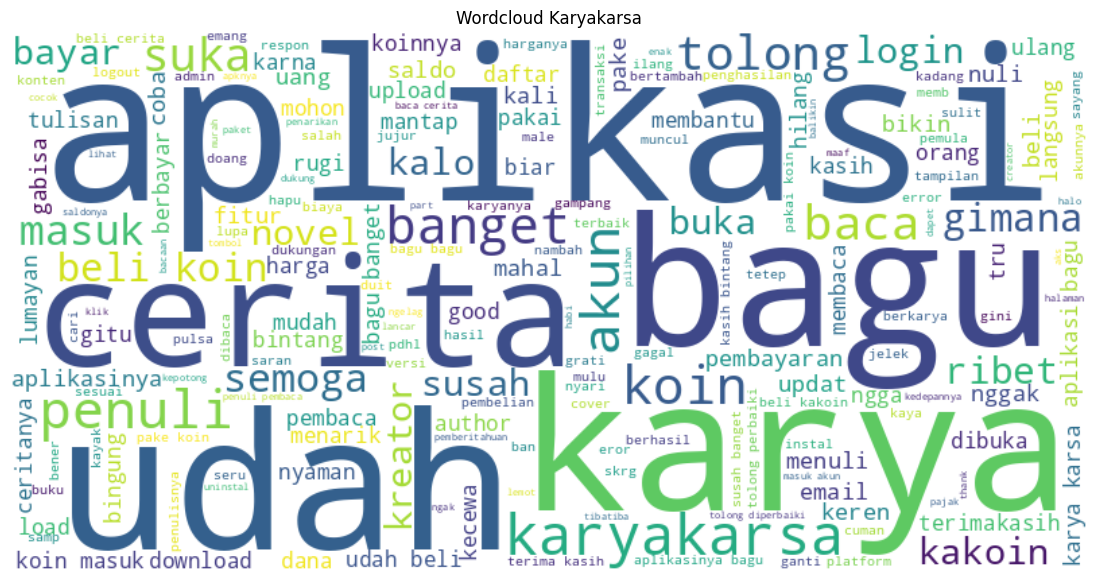

In [23]:
karyakarsa_words = ' '.join(df[df['app']=='Karyakarsa']['clean_text'])
wordcloud_karyakarsa = WordCloud(width=800, height=400, background_color='white').generate(karyakarsa_words)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud_karyakarsa, interpolation='bilinear')
plt.axis('off')
plt.title("Wordcloud Karyakarsa")
plt.show()

webtoon 3483
bagu 2833
baca 2568
komik 1920
banget 1840
aplikasi 1788
koin 1645
suka 1554
udah 1453
tolong 1402
cerita 1078
iklan 1033
buka 830
kalo 830
updat 797
pake 774
beli 715
kasih 590
seru 581
download 535


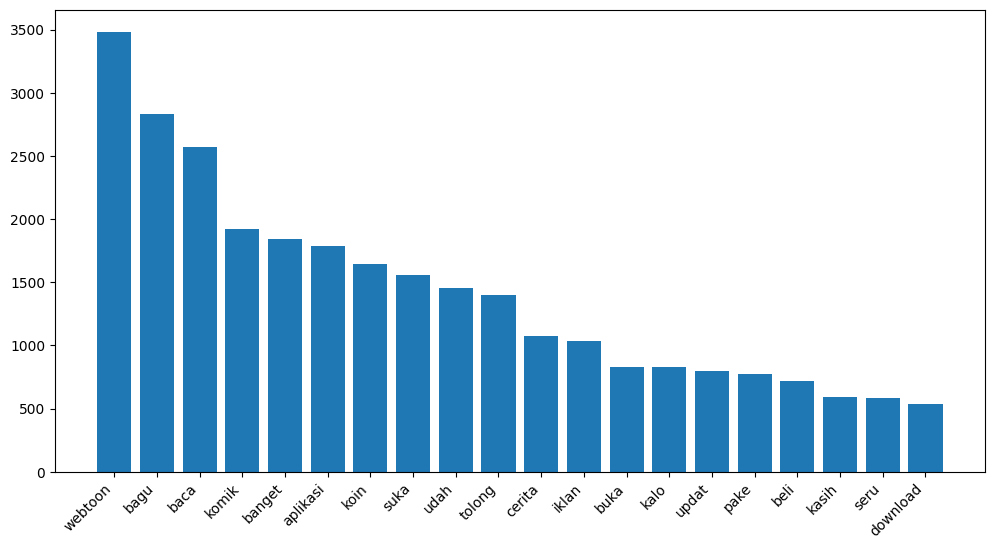

In [25]:
#N-gram (unigram, bigram, trigram, 4-gram)
vectorizer = CountVectorizer(ngram_range=(1,4))
X = vectorizer.fit_transform(df['clean_text'])
sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

# Tampilkan top 20 n-gram
for word, freq in words_freq[:20]:
    print(word, freq)

# Visualisasi n-gram top 20
top_words = dict(words_freq[:20])
plt.figure(figsize=(12,6))
plt.bar(top_words.keys(), top_words.values())
plt.xticks(rotation=45, ha='right')
plt.show()

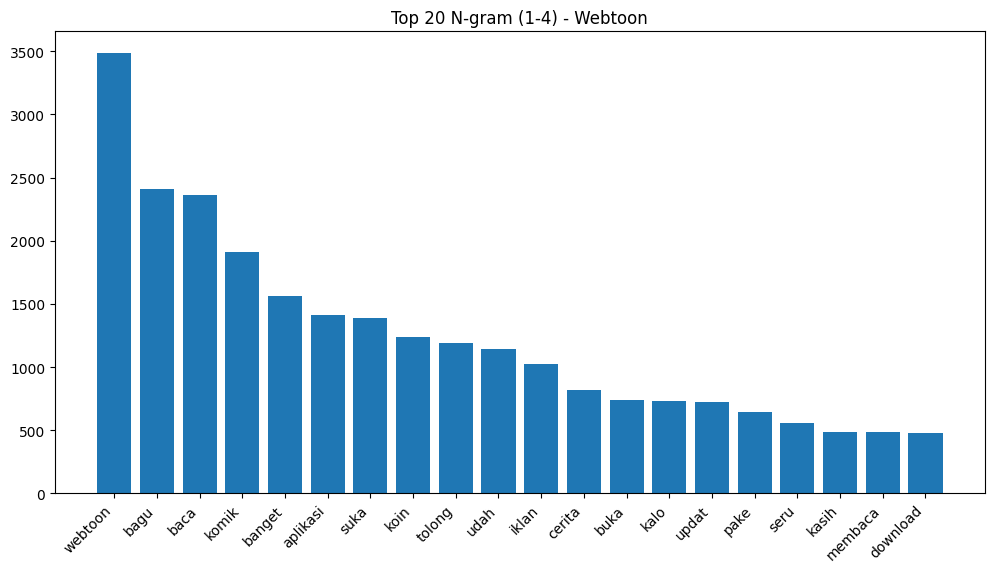

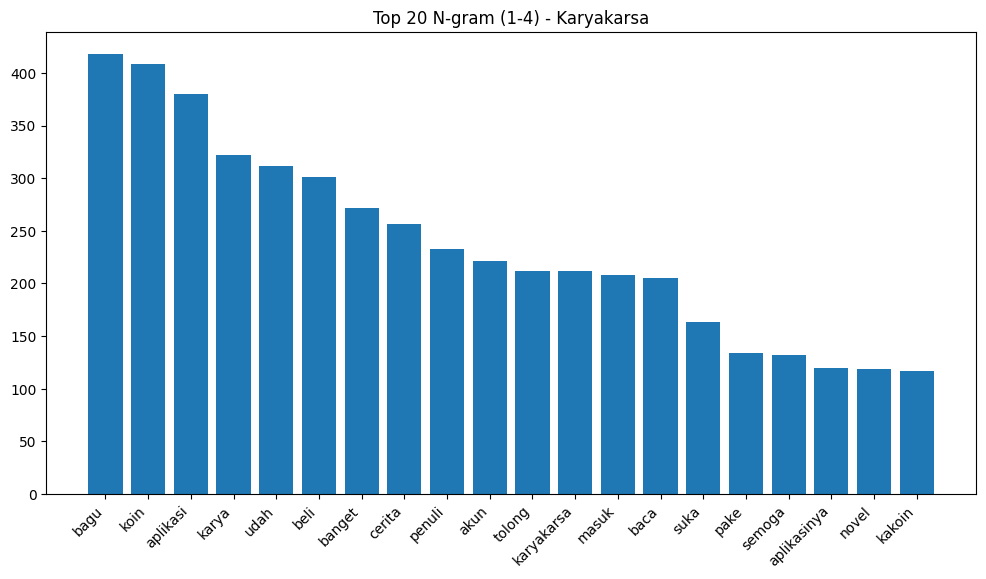

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

def plot_top_ngrams(texts, app_name, ngram_range=(1,4), top_n=20):
    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(texts)
    sum_words = X.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    top_words = dict(words_freq[:top_n])

    plt.figure(figsize=(12,6))
    plt.bar(top_words.keys(), top_words.values())
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Top {top_n} N-gram ({ngram_range[0]}-{ngram_range[1]}) - {app_name}")
    plt.show()

# N-gram Webtoon
plot_top_ngrams(df[df['app']=='Webtoon']['clean_text'], app_name='Webtoon', ngram_range=(1,4), top_n=20)

# N-gram Karyakarsa
plot_top_ngrams(df[df['app']=='Karyakarsa']['clean_text'], app_name='Karyakarsa', ngram_range=(1,4), top_n=20)


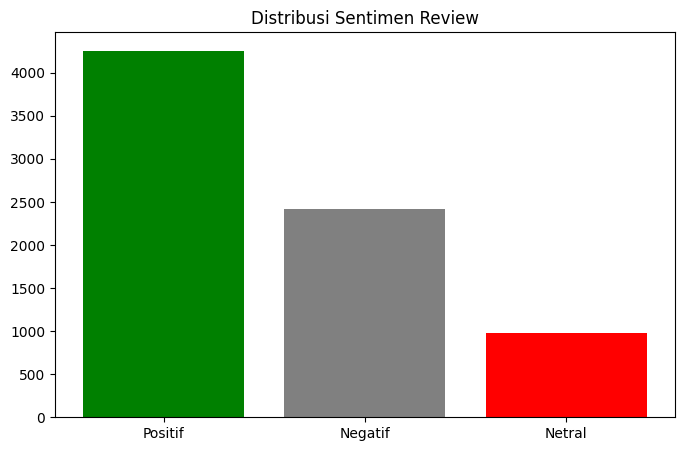

In [26]:
#Pelabelan sentimen
def label_sentiment(score):
    if score >= 4:
        return 'Positif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Negatif'

df['sentiment'] = df['score'].apply(label_sentiment)

# Visualisasi jumlah sentimen
sentiment_counts = df['sentiment'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green','grey','red'])
plt.title('Distribusi Sentimen Review')
plt.show()

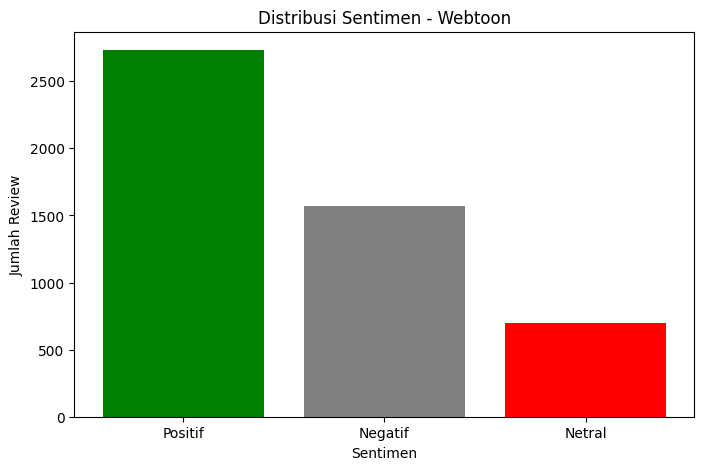

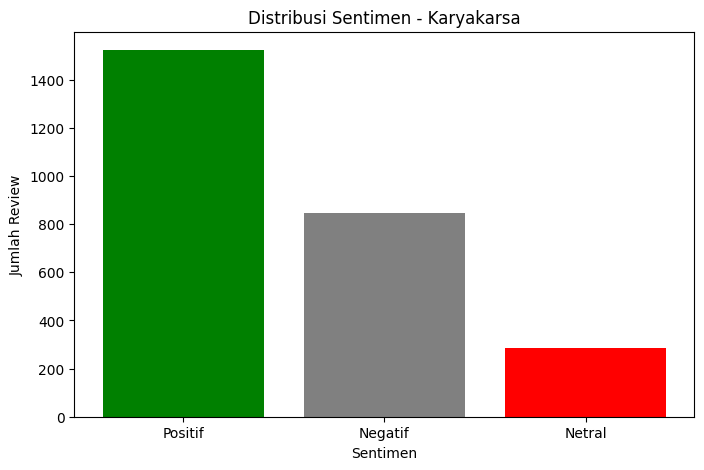

In [15]:
import matplotlib.pyplot as plt

# Fungsi pelabelan sentimen
def label_sentiment(score):
    if score >= 4:
        return 'Positif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Negatif'

# Terapkan pelabelan
df['sentiment'] = df['score'].apply(label_sentiment)

# Fungsi visualisasi sentimen per aplikasi
def plot_sentiment(df_app, app_name):
    sentiment_counts = df_app['sentiment'].value_counts()
    plt.figure(figsize=(8,5))
    plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green','grey','red'])
    plt.title(f'Distribusi Sentimen - {app_name}')
    plt.xlabel('Sentimen')
    plt.ylabel('Jumlah Review')
    plt.show()

# Visualisasi sentimen Webtoon
plot_sentiment(df[df['app']=='Webtoon'], 'Webtoon')

# Visualisasi sentimen Karyakarsa
plot_sentiment(df[df['app']=='Karyakarsa'], 'Karyakarsa')


In [27]:
#Clustering (K-Means)
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_tfidf)

In [11]:
# 8. Topic Modeling (LDA)
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X_tfidf)
for i, topic in enumerate(lda.components_):
    top_words = [tfidf.get_feature_names_out()[index] for index in topic.argsort()[-10:]]
    print(f"Topic {i+1}: {', '.join(top_words)}")

Topic 1: load, keren, perbaiki, lancar, jaringan, udah, baca, tolong, webtoon, buka
Topic 2: akun, webtoon, masuk, suka, karya, komik, beli, aplikasi, koin, bagu
Topic 3: tampilan, iklan, seru, cerita, suka, webtoon, komik, banget, baca, bagu


In [ ]:
# 9. Simpan hasil
df.to_csv('mini_project_reviews.csv', index=False)